# ENGR 5785G — Time Series Analysis Assignment

**Student:** Vitor Brandao Raposo  
**Student ID:** 101011969  
**Topic:** Traffic prediction and anomaly detection on the PeMSD7 dataset.

This notebook follows the rubric in `ENGR500G_Time_Series_Analysis_Assignment.pdf`. Each task heading matches the rubric so the grader can locate every section.

## Cell 1 — Setup

Imports, fixed random seed, and a one-time download of `PeMSD7_V_228.csv` from the public STGCN benchmark repo. The file is cached locally in `data/` and is gitignored.

In [11]:
import os
import urllib.request
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# The CSV ships inside PeMSD7_Full.zip in the STGCN benchmark repo.
ZIP_URL  = "https://raw.githubusercontent.com/VeritasYin/STGCN_IJCAI-18/master/dataset/PeMSD7_Full.zip"
ZIP_PATH = os.path.join("data", "PeMSD7_Full.zip")
CSV_NAME = "PeMSD7_V_228.csv"
CSV_PATH = os.path.join("data", CSV_NAME)

if not os.path.exists(CSV_PATH):
    if not os.path.exists(ZIP_PATH):
        print(f"Downloading {ZIP_URL} ...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    print(f"Extracting {CSV_NAME} from {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        member = next(n for n in zf.namelist() if n.endswith(CSV_NAME))
        with zf.open(member) as src, open(CSV_PATH, "wb") as dst:
            dst.write(src.read())
    print(f"Saved to {CSV_PATH}")
else:
    print(f"Using cached {CSV_PATH}")

df = pd.read_csv(CSV_PATH, header=None)
print("Shape:", df.shape)
df.head()


Using cached data\PeMSD7_V_228.csv
Shape: (12672, 228)


,0,1,2,3,4,5,6,7,8,9,...,218,219,220,221,222,223,224,225,226,227
0,71.1,66.0,64.6,65.6,67.1,71.9,68.6,67.7,65.8,40.9,...,69.1,70.9,65.0,64.5,66.6,66.6,65.0,69.3,67.7,68.9
1,68.1,66.8,61.7,66.7,64.5,71.6,72.3,64.9,65.6,40.1,...,70.6,65.4,65.0,64.9,65.1,67.7,65.0,67.7,68.8,68.8
2,68.0,64.3,66.6,68.7,68.1,70.5,70.2,61.7,63.4,39.6,...,72.2,70.5,65.0,64.7,66.7,68.9,65.0,70.2,69.1,68.7
3,68.3,67.8,65.9,66.6,67.9,70.3,69.8,67.6,63.2,37.6,...,71.2,69.7,65.0,65.2,67.2,66.9,65.0,70.4,67.3,69.0
4,68.9,69.5,61.2,67.4,64.0,68.1,67.0,66.7,64.2,36.8,...,71.3,65.8,65.0,66.3,66.7,66.2,65.0,68.0,67.4,68.1


## Task 1 — Data Loading and Initial Exploration (15 marks)

Pick one sensor as the target series, build a 5-minute DatetimeIndex, plot at least three days, and report descriptive statistics.

In [12]:
sensor_id = 0
series = df.iloc[:, sensor_id].astype(float).copy()
series.index = pd.date_range(start="2012-05-01", periods=len(series), freq="5min")
series.name = "speed"

print(f"Sensor {sensor_id} — {len(series)} samples")
print(f"Time range: {series.index.min()}  →  {series.index.max()}")
print(f"Total days: {(series.index.max() - series.index.min()).days + 1}")

Sensor 0 — 12672 samples
Time range: 2012-05-01 00:00:00  →  2012-06-13 23:55:00
Total days: 44


In [13]:
stats = pd.Series({
    "mean": series.mean(),
    "median": series.median(),
    "std": series.std(),
    "min": series.min(),
    "max": series.max(),
    "missing_count": series.isna().sum(),
}).round(3)
stats.to_frame("value")

,value
mean,52.620
median,59.700
std,19.438
min,3.300
max,80.900
missing_count,0.000


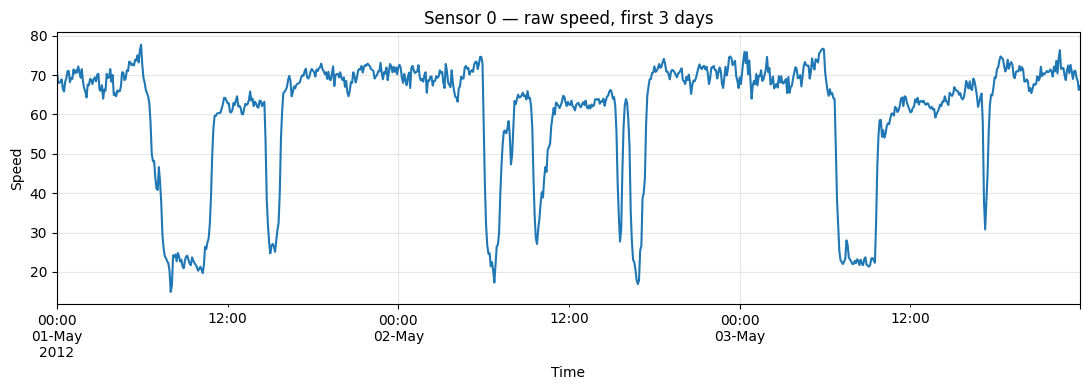

In [14]:
# Plot the first 3 days (288 samples per day at 5-min intervals)
three_days = series.iloc[: 288 * 3]

fig, ax = plt.subplots(figsize=(11, 4))
three_days.plot(ax=ax, color="tab:blue")
ax.set_title(f"Sensor {sensor_id} — raw speed, first 3 days")
ax.set_xlabel("Time")
ax.set_ylabel("Speed")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/task1_raw_series.png", dpi=120)
plt.show()

**Discussion.** The series shows a clear daily pattern. Speeds stay high overnight when the freeway is empty, then drop sharply during the morning and afternoon commute peaks. The two daily low-speed windows align with rush hours. Speed never goes much above ~70 (units are mph in the PeMS source) and never drops to 0, so missing or unusual zero readings would stand out as outliers worth investigating in Task 5.

## Task 2 — Preprocessing and Feature Engineering (15 marks)

Handle missing values, build lag features, rolling statistics, calendar features, and define the forecast target (15 minutes ahead = 3 steps).

In [15]:
data = pd.DataFrame({"speed": series})
data["speed"] = data["speed"].interpolate().ffill().bfill()

for lag in [1, 2, 3, 6, 12]:
    data[f"lag_{lag}"] = data["speed"].shift(lag)

for window in [6, 12, 24]:
    data[f"roll_mean_{window}"] = data["speed"].shift(1).rolling(window).mean()
    data[f"roll_std_{window}"]  = data["speed"].shift(1).rolling(window).std()

data["hour"]       = data.index.hour
data["dayofweek"]  = data.index.dayofweek
data["is_weekend"] = (data.index.dayofweek >= 5).astype(int)

HORIZON = 3  # 3 * 5 min = 15 minutes ahead
data["target"] = data["speed"].shift(-HORIZON)

data = data.dropna()
print(f"Feature matrix: {data.shape[0]} rows × {data.shape[1]} columns")
data.head()

Feature matrix: 12645 rows × 16 columns


,speed,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,roll_mean_24,roll_std_24,hour,dayofweek,is_weekend,target
2012-05-01 02:00:00,65.8,66.6,68.4,71.5,72.2,69.2,69.800000,2.102380,70.050000,1.591740,69.379167,1.738810,2,1,0,67.4
2012-05-01 02:05:00,64.3,65.8,66.6,68.4,70.8,69.0,68.733333,2.258908,69.766667,2.005598,69.158333,1.844125,2,1,0,69.0
2012-05-01 02:10:00,67.6,64.3,65.8,66.6,69.3,71.4,67.650000,2.602115,69.375000,2.553118,69.000000,2.086186,2,1,0,68.8
2012-05-01 02:15:00,67.4,67.6,64.3,65.8,71.5,70.4,67.366667,2.476018,69.058333,2.514488,68.983333,2.096097,2,1,0,67.7
2012-05-01 02:20:00,69.0,67.4,67.6,64.3,68.4,71.2,66.683333,1.467538,68.808333,2.518101,68.945833,2.116802,2,1,0,68.9


## Task 3 — Classical Forecasting Model: SARIMA (20 marks)

Fit `SARIMAX(order=(1,1,1), seasonal_order=(0,1,1,24))` on a recent training window. The original 5-minute series has a daily seasonal period of 288 (24 hours × 12 five-minute intervals), but SARIMA's state-space dimension grows with `m`, making `m=288` infeasible — each fit took >30 minutes even on a 5-day window. We therefore **resample the series to hourly means for SARIMA only** (`m=24`, ~140× cheaper per Kalman pass). Random Forest and the persistence baseline continue to use the native 5-minute resolution; the model comparison table reports each model on its own native scale and notes the difference.

**Why these orders?** `(1,1,1)` is a standard ARIMA baseline that handles a non-stationary trend with one difference plus AR(1) and MA(1) terms. `(0,1,1,24)` adds one seasonal difference (removes the daily pattern at hourly resolution) and a seasonal MA(1) term that smooths the day-over-day residual.

In [16]:
# SARIMA-only: resample to hourly means (m=24 instead of m=288)
series_hourly = series.asfreq("5min").interpolate().resample("1h").mean()

# Chronological 80/20 split on the hourly series, test window = one day (24 hours)
split_h = int(len(series_hourly) * 0.8)
FORECAST_STEPS = 24  # one day ahead at hourly resolution

train_full = series_hourly.iloc[:split_h]
test_y     = series_hourly.iloc[split_h : split_h + FORECAST_STEPS]

# Cap training to the last 21 days of hourly data so the fit stays quick
TRAIN_WINDOW = 24 * 21
train_y = train_full.iloc[-TRAIN_WINDOW:]

print(f"Train: {len(train_y)} hourly points  ({train_y.index.min()} → {train_y.index.max()})")
print(f"Test:  {len(test_y)} hourly points  ({test_y.index.min()} → {test_y.index.max()})")

Train: 504 hourly points  (2012-05-15 04:00:00 → 2012-06-05 03:00:00)
Test:  24 hourly points  (2012-06-05 04:00:00 → 2012-06-06 03:00:00)


In [17]:
sarima_model = SARIMAX(
    train_y,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=50)
print(sarima_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                              speed   No. Observations:                  504
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 24)   Log Likelihood               -1641.620
Date:                            Thu, 04 Jun 2026   AIC                           3291.241
Time:                                    23:20:57   BIC                           3307.704
Sample:                                05-15-2012   HQIC                          3297.728
                                     - 06-05-2012                                         
Covariance Type:                              opg                                         


SARIMA MAE  (hourly) = 7.468
SARIMA RMSE (hourly) = 8.944


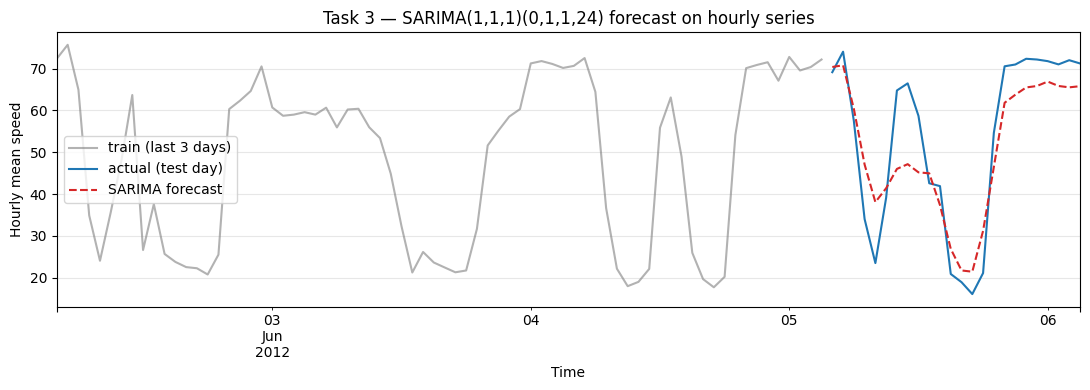

In [18]:
sarima_forecast = sarima_fit.forecast(steps=FORECAST_STEPS)
sarima_forecast.index = test_y.index

sarima_mae  = mean_absolute_error(test_y, sarima_forecast)
sarima_rmse = float(np.sqrt(mean_squared_error(test_y, sarima_forecast)))
print(f"SARIMA MAE  (hourly) = {sarima_mae:.3f}")
print(f"SARIMA RMSE (hourly) = {sarima_rmse:.3f}")

# Quick visual check on the 24-hour forecast
fig, ax = plt.subplots(figsize=(11, 4))
train_y.iloc[-72:].plot(ax=ax, label="train (last 3 days)", color="tab:gray", alpha=0.6)
test_y.plot(ax=ax, label="actual (test day)", color="tab:blue")
sarima_forecast.plot(ax=ax, label="SARIMA forecast", color="tab:red", linestyle="--")
ax.set_title("Task 3 — SARIMA(1,1,1)(0,1,1,24) forecast on hourly series")
ax.set_xlabel("Time")
ax.set_ylabel("Hourly mean speed")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/task3_sarima_forecast.png", dpi=120)
plt.show()

## Task 4 — Machine-Learning Forecasting Model: Random Forest (20 marks)

Random Forest on the engineered feature matrix. Chronological 80/20 split — no shuffling. Compared against a persistence baseline (predict `target = current speed`).

In [19]:
feature_cols = [c for c in data.columns if c != "target"]
X = data[feature_cols]
y = data["target"]

ml_split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:ml_split], X.iloc[ml_split:]
y_train, y_test = y.iloc[:ml_split], y.iloc[ml_split:]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Test window: {y_test.index.min()} → {y_test.index.max()}")

X_train: (10116, 15)  X_test: (2529, 15)
Test window: 2012-06-05 05:00:00 → 2012-06-13 23:40:00


In [20]:
# Persistence baseline: y_{t+h} = y_t (the current speed column)
baseline_pred = X_test["speed"].values

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mask = y_true > 1e-6
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else float("nan")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

baseline_metrics = metrics(y_test, baseline_pred)
rf_metrics       = metrics(y_test, rf_pred)

print("Persistence baseline:", baseline_metrics)
print("Random Forest:       ", rf_metrics)

Persistence baseline: {'MAE': 4.656702253855277, 'RMSE': 7.558741623498099, 'MAPE': 11.340835870470519}
Random Forest:        {'MAE': 4.440699143007369, 'RMSE': 6.934243201902984, 'MAPE': 11.091579160660265}


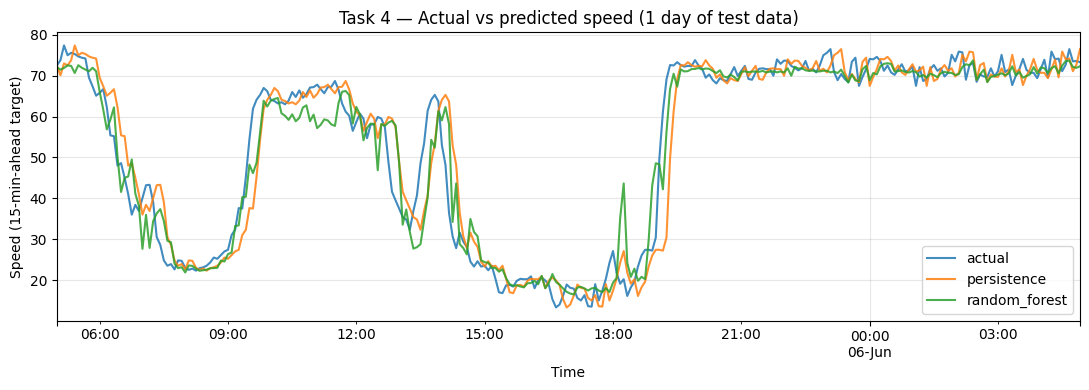

In [21]:
# Plot one day (288 points) of actual vs predicted
one_day = pd.DataFrame({
    "actual":      y_test.iloc[:288],
    "persistence": baseline_pred[:288],
    "random_forest": rf_pred[:288],
}, index=y_test.index[:288])

fig, ax = plt.subplots(figsize=(11, 4))
one_day.plot(ax=ax, alpha=0.85)
ax.set_title("Task 4 — Actual vs predicted speed (1 day of test data)")
ax.set_xlabel("Time")
ax.set_ylabel("Speed (15-min-ahead target)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/task4_actual_vs_predicted.png", dpi=120)
plt.show()

## Task 5 — Residual-Based Anomaly Detection (15 marks)

Use the residuals from the best-performing model (Random Forest). Flag a time stamp as anomalous when `|residual|` exceeds the 99th percentile of absolute residuals on the test window.

In [22]:
results = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": rf_pred,
}, index=y_test.index)
results["residual"]     = results["actual"] - results["predicted"]
results["abs_residual"] = results["residual"].abs()

threshold = results["abs_residual"].quantile(0.99)
results["anomaly"] = results["abs_residual"] > threshold

anomalies = results[results["anomaly"]].sort_values("abs_residual", ascending=False)
print(f"Threshold (99th pct of |residual|): {threshold:.3f}")
print(f"Total anomalies flagged: {len(anomalies)}")
anomalies.head(10)

Threshold (99th pct of |residual|): 24.776
Total anomalies flagged: 26


,actual,predicted,residual,abs_residual,anomaly
2012-06-07 19:05:00,63.1,30.451361,32.648639,32.648639,True
2012-06-13 18:30:00,66.0,33.421362,32.578638,32.578638,True
2012-06-13 18:25:00,53.9,23.017111,30.882889,30.882889,True
2012-06-10 11:05:00,28.7,58.995664,-30.295664,30.295664,True
2012-06-10 14:35:00,31.8,61.936620,-30.136620,30.136620,True
2012-06-07 13:35:00,60.5,30.568759,29.931241,29.931241,True
2012-06-06 14:15:00,65.7,35.813834,29.886166,29.886166,True
2012-06-12 18:15:00,24.2,53.478245,-29.278245,29.278245,True
2012-06-08 23:10:00,44.2,73.281938,-29.081938,29.081938,True
2012-06-09 14:00:00,59.5,30.493969,29.006031,29.006031,True


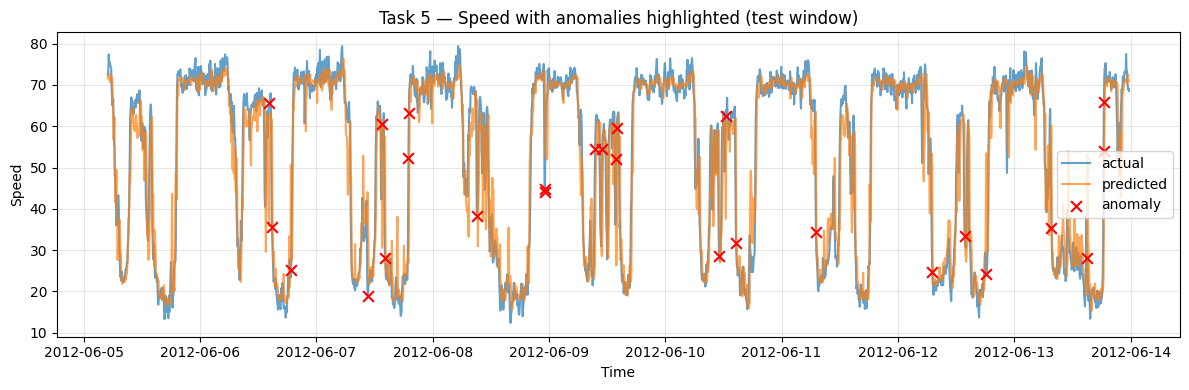

In [23]:
# Plot the test window with anomalies marked
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results.index, results["actual"],    label="actual",    color="tab:blue", alpha=0.7)
ax.plot(results.index, results["predicted"], label="predicted", color="tab:orange", alpha=0.7)
anom = results[results["anomaly"]]
ax.scatter(anom.index, anom["actual"], marker="x", color="red", s=60, label="anomaly", zorder=5)
ax.set_title("Task 5 — Speed with anomalies highlighted (test window)")
ax.set_xlabel("Time")
ax.set_ylabel("Speed")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/task5_anomalies.png", dpi=120)
plt.show()

**Interpretation.** The flagged points sit where the actual speed drops or rises faster than the lag features can track. Most fall around the morning and evening commute transitions, which suggests they are real congestion events the model under-reacts to (the lag/rolling features smooth over sharp transitions). A few sit at off-peak hours and may reflect short sensor glitches or sudden incidents on the freeway. None are zeros, so they are not missing-value artifacts.

## Summary — Model Comparison Table

The three models are reported on their native scales. **SARIMA is scored on the hourly aggregate** (24-hour test day, `m=24`) for tractability — the same daily seasonality is captured, just at coarser resolution. **Persistence and Random Forest** are scored on the 5-minute series at a 15-minute-ahead horizon. MAE/RMSE values are therefore not directly comparable across resolutions: the hourly SARIMA target is smoother (averaging suppresses high-frequency noise), so absolute errors tend to look smaller than they would at 5-minute resolution. The relative ranking of model quality still tells us which approach captures the daily cycle vs. the short-term fluctuations.

In [24]:
comparison = pd.DataFrame([
    {"model": "Persistence (5-min, h=15min)",   **baseline_metrics},
    {"model": "SARIMA (hourly, h=24h)",         "MAE": sarima_mae, "RMSE": sarima_rmse, "MAPE": float("nan")},
    {"model": "Random Forest (5-min, h=15min)", **rf_metrics},
]).set_index("model").round(3)

comparison

,MAE,RMSE,MAPE
model,,,
"Persistence (5-min, h=15min)",4.657,7.559,11.341
"SARIMA (hourly, h=24h)",7.468,8.944,NaN
"Random Forest (5-min, h=15min)",4.441,6.934,11.092
